In [15]:
from dotenv import load_dotenv
load_dotenv()

True

In [16]:
from langchain.chat_models import init_chat_model
from langchain_core.output_parsers import StrOutputParser

model = init_chat_model("google_genai:gemini-3.1-flash-lite")

chain = model | StrOutputParser()

In [17]:
from typing import TypedDict, Literal

class State(TypedDict):
    value: int
    decision: Literal["even", "odd"]

In [18]:
from langchain.messages import SystemMessage, HumanMessage

def check_condition_node(state: State):
    print("check_condition_node 실행")
    print(f"value = {state['value']}")

    system_prompt = (
        "당신은 업무흐름을 라우팅하는 어시스턴트입니다."
        "숫자가 짝수면 'even', 홀수면 'odd' 만 정확히 출력하세요."
        "추가 설명이나 다른 텍스트는 절대 출력하지 마세요."
    )

    user_prompt = f"숫자 {state['value']}는 짝수인가요, 홀수인가요?"

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt)
    ]

    response = chain.invoke(messages)
    decision = response.strip().lower()

    print(f"LLM 응답: {decision}")

    return {"decision": decision}

In [19]:
def even_node(state: State):
    print("짝수 노드입니다.")
    return state

In [20]:
def odd_node(state: State):
    print("홀수 노드입니다.")
    return state

In [21]:
def router(state: State) -> Literal["even", "odd"]:
    print("라우터 실행")
    print(f"decision: {state['decision']}")

    if state["decision"] == "even":
        print("라우터: 짝수 노드로 이동")
        return "even"
    else:
        print("라우터: 홀수 노드로 이동")
        return "odd"

In [22]:
from langgraph.graph import StateGraph, START, END

graph_builder = StateGraph(State)

graph_builder.add_node(check_condition_node)
graph_builder.add_node(even_node)
graph_builder.add_node(odd_node)

graph_builder.add_edge(START,"check_condition_node")
graph_builder.add_conditional_edges(
    "check_condition_node",
    router,
    {
        "even": "even_node",
        "odd": "odd_node",
    }
)

graph_builder.add_edge("even_node", END)
graph_builder.add_edge("odd_node", END)

graph = graph_builder.compile()

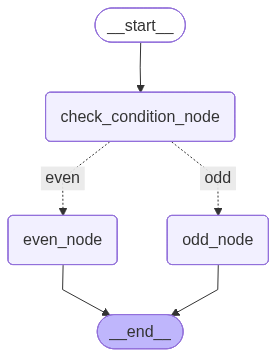

In [23]:
graph

In [24]:
graph.invoke({"value": 1})

check_condition_node 실행
value = 1
LLM 응답: odd
라우터 실행
decision: odd
라우터: 홀수 노드로 이동
홀수 노드입니다.


{'value': 1, 'decision': 'odd'}

In [25]:
graph.invoke({"value": 2})

check_condition_node 실행
value = 2
LLM 응답: even
라우터 실행
decision: even
라우터: 짝수 노드로 이동
짝수 노드입니다.


{'value': 2, 'decision': 'even'}